<a href="https://colab.research.google.com/github/crossbone72/AI-Class/blob/main/weak4/titanic_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'

df = pd.read_csv(path)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [96]:
#결측치 확인
print("---결측치 확인---")
print(df.isnull().sum())

---결측치 확인---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [97]:
#나이는 평균으로 채우고, 객실 번호는 삭제, 항구는 최빈값(가장 많이 나온 값)으로 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.drop(columns=['Cabin'], inplace=True)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [98]:
#Label Encoding
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [99]:
#Label 개수 확인
print("--- 생존자/사망자 비율 ---")
print(df['Survived'].value_counts())

--- 생존자/사망자 비율 ---
Survived
0    549
1    342
Name: count, dtype: int64


In [100]:
#Feature Selection
#분석에 불필요한 이름, 티켓번호, 승객ID는 제외하고 학습 데이터 구성
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
X = df[features]
y = df['Survived']

print("--- 전처리 완료된 데이터 확인 ---")
print(X.head())

--- 전처리 완료된 데이터 확인 ---
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500         2
1       1    0  38.0      1      0  71.2833         0
2       3    0  26.0      0      0   7.9250         2
3       1    0  35.0      1      0  53.1000         2
4       3    1  35.0      0      0   8.0500         2


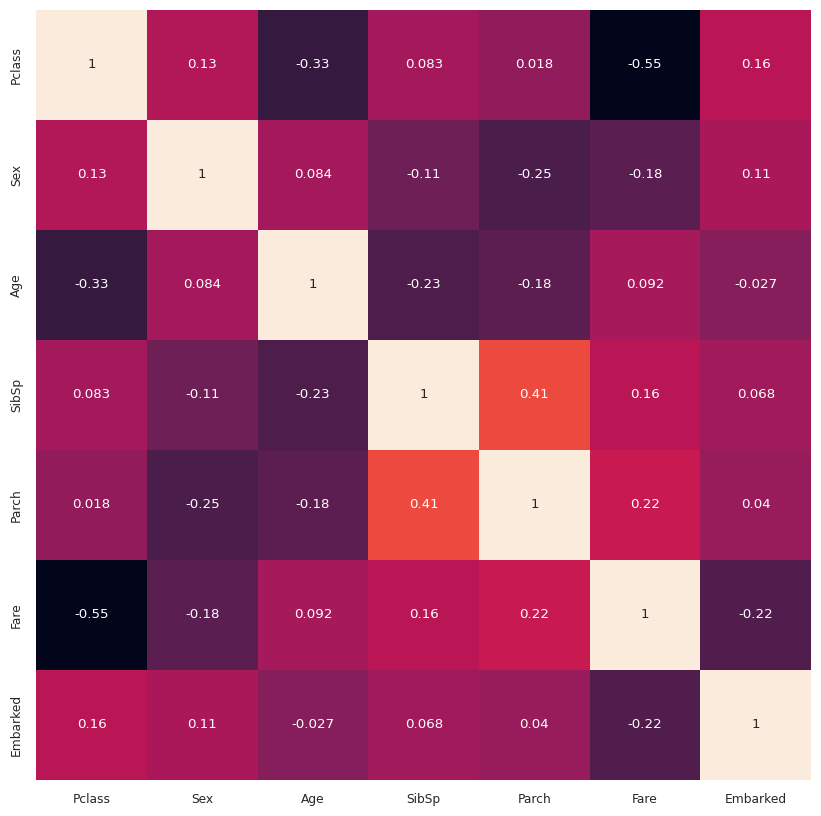

In [101]:
#상관 관계 행렬
# 0.3 이상인 경우 상관관계가 있고, 0.7이상이면 아주 높음
df_corr=X.corr()

plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [103]:
clf_lr = LogisticRegression(max_iter=500) #최대 500번 반복해서 최대한 오차가 적은 모델 만들기
clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)

print("\n--- Logistic Regression ---")
print(accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))


--- Logistic Regression ---
0.7988826815642458
[[92 18]
 [18 51]]


In [104]:
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)
pred_dt = clf_dt.predict(X_test)

print("\n--- Decision Tree Classifier ---")
print(accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))


--- Decision Tree Classifier ---
0.7877094972067039
[[94 16]
 [22 47]]


In [105]:
clf_rf = RandomForestClassifier(random_state=0)
clf_rf.fit(X_train, y_train)
pred_rf = clf_rf.predict(X_test)

print("\n--- Random Forest Classifier ---")
print(accuracy_score(y_test, pred_rf))
print(confusion_matrix(y_test, pred_rf))


--- Random Forest Classifier ---
0.8435754189944135
[[100  10]
 [ 18  51]]
